In [1]:
# ------------------------------------------------------------
# Setup & Repo
# ------------------------------------------------------------

# import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

# call repository
!rm -rf PGST
!git clone --quiet https://github.com/mickdeines/PGST/
os.chdir("PGST")

In [2]:
# ------------------------------------------------------------
# Load Cleaned Data
# ------------------------------------------------------------

# propane deliveries and daily temperatures
deliveries_df = pd.read_csv("Propane Deliveries 2005-2025.csv")
daily_temps_df = pd.read_csv("ERA5 Daily Temperatures 2015-2026.csv")

print(deliveries_df.head())
print(daily_temps_df.head())

         date    description  gallons  sale_amount
0  2005-07-26   PROPANE BULK    449.9       651.91
1  2005-10-24   PROPANE BULK   1361.2      2775.49
2  2005-10-27   PROPANE BULK    313.0       638.21
3  2005-11-18   PROPANE BULK   1300.0      2715.70
4  2005-12-06  PROPANE INDEX   1300.0      2299.96
         Date       Tavg       Tmin       Tmax
0  2014-12-31  34.941023  33.693575  36.165514
1  2015-01-01  36.051964  32.801396  39.670727
2  2015-01-02  38.744935  36.571404  41.051563
3  2015-01-03  40.491788  39.675817  41.474407
4  2015-01-04  43.902947  40.192933  49.539857


In [3]:
# ----------------------------
# Helpers
# ----------------------------
def piecewise_fit(df, Tb=60, x="temp_F", y="gallons"):
    heat = df[df[x] < Tb]
    base = df[df[x] >= Tb]
    m, b = np.polyfit(heat[x].astype(float), heat[y].astype(float), 1)
    baseline = float(base[y].mean()) if len(base) else float(df[y].mean())
    return m, b, baseline

def piecewise_r2(df, m, b, baseline, Tb=60, x="temp_F", y="gallons"):
    heat = df[df[x] < Tb]
    base = df[df[x] >= Tb]

    def r2(y_true, y_pred):
        y_true = np.asarray(y_true, float)
        y_pred = np.asarray(y_pred, float)
        denom = np.sum((y_true - y_true.mean()) ** 2)
        return np.nan if denom == 0 else 1 - np.sum((y_true - y_pred) ** 2) / denom

    r2_heat = r2(heat[y], m * heat[x] + b) if len(heat) >= 2 else np.nan
    r2_base = r2(base[y], np.full(len(base), baseline)) if len(base) >= 2 else np.nan
    return r2_heat, r2_base

def sweep_Tb(df, Tb_grid, x="temp_F", y="gallons"):
    rows = []
    for Tb in Tb_grid:
        m, b, baseline = piecewise_fit(df, Tb=Tb, x=x, y=y)
        r2h, r2b = piecewise_r2(df, m, b, baseline, Tb=Tb, x=x, y=y)
        rows.append({"Tb_F": Tb, "m": m, "b": b, "baseline": baseline, "r2_heat": r2h, "r2_base": r2b})
    return pd.DataFrame(rows)

def plot_piecewise(
    df, m, b, baseline, Tb=60,
    x="temp_F", y="gal_per_day",
    title="Propane Consumption vs. Outdoor Temperature (2023–2025)",
    figsize=(12, 5),
    outliers_df=None,
    r2_heat=None,
    n_removed=0,
    stats_in_plot=True,
    save_path=None,
    dpi=300,
):
    below = df[df[x] < Tb]
    above = df[df[x] >= Tb]

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")

    # main data
    ax.scatter(
        df[x], df[y],
        color="steelblue", alpha=0.45, s=35,
        zorder=3, label="Delivery window"
    )

    # removed outliers
    if outliers_df is not None and len(outliers_df):
        ax.scatter(
            outliers_df[x], outliers_df[y],
            facecolors="none", edgecolors="tomato",
            s=60, linewidths=1.5,
            zorder=4, label=f"Removed outlier"
        )

    # heating fit
    if len(below):
        xs = np.linspace(below[x].min(), Tb, 200)
        label_heat = f"Space heating load fit"
        ax.plot(
            xs, m * xs + b,
            color="navy", linewidth=2.5,
            label=label_heat, zorder=5
        )

    # baseline fit
    if len(above):
        xs = np.linspace(Tb, above[x].max(), 200)
        ax.plot(
            xs, np.full_like(xs, baseline),
            color="firebrick", linewidth=2.5,
            label="Baseline load fit",
            zorder=5
        )

    # balance point reference
    ax.axvline(
        Tb, color="gray", linestyle="--",
        linewidth=1.4, alpha=0.75, zorder=2
    )

    ymin, ymax = ax.get_ylim()
    ax.text(
        Tb + 0.39, ymax * 0.9,
        f"Balance point\n{Tb}°F",
        fontsize=14, color="gray", va="top"
    )

    # original stats box
    if stats_in_plot:
        stats_text = (
            f"Space heating:  slope = {m:.2f} gal/day/°F\n"
            f"                intercept = {b:.1f} gal/day\n"
            f"                R² = {r2_heat:.3f}\n\n"
            f"Baseline load:  {baseline:.1f} gal/day"
        )
        ax.text(
            0.46, 0.83, stats_text,
            transform=ax.transAxes,
            fontsize=11.5, va="top", ha="left",
            bbox=dict(
                boxstyle="round,pad=0.4",
                facecolor="white",
                edgecolor="lightgray",
                alpha=0.85
            ),
            family="monospace"
        )

    ax.set_xlabel("Average Temperature (°F)", fontsize=13)
    ax.set_ylabel("Propane consumption (gal/day)", fontsize=13)
    ax.set_title(title, fontsize=22, fontweight="bold", pad=10)
    ax.tick_params(labelsize=11)
    ax.legend(fontsize=14, framealpha=0.9)
    ax.grid(True, linestyle="--", alpha=0.35)

    plt.tight_layout()
    plt.show()

In [4]:
# ----------------------------
# Config
# ----------------------------
WINDOW_START_YEAR = 2023
WINDOW_END_YEAR   = 2025
Tb0               = 60                 # main fit temp breakpoint
TB_SWEEP          = np.arange(50, 71)  # sweep range
N_OUTLIERS        = 2

PARAMS_JSON_PATH  = "regression_params.json"
WINDOW_CSV_PATH   = f"Propane Regression Delivery Windows {WINDOW_START_YEAR}-{WINDOW_END_YEAR}.csv"

In [5]:
# ----------------------------
# Build daily temps (NEW temps)
# daily_temps_df expected columns: Date, Tavg (F)
# ----------------------------
daily_t = daily_temps_df.copy()
daily_t["Date"] = pd.to_datetime(daily_t["Date"])
daily_t["Tavg"] = pd.to_numeric(daily_t["Tavg"], errors="coerce")
daily_for_join = (
    daily_t.dropna(subset=["Date", "Tavg"])[["Date", "Tavg"]].rename(columns={"Date": "date", "Tavg": "temp_F"}).sort_values("date").reset_index(drop=True)
)

In [6]:
# ----------------------------
# Build delivery chunks (intervals) + interval-average temp + gal/day
# ----------------------------
d = deliveries_df.copy()
d["date"] = pd.to_datetime(d["date"])
d["gallons"] = pd.to_numeric(d["gallons"], errors="coerce")
d = d.dropna(subset=["date", "gallons"]).sort_values("date").reset_index(drop=True)

chunks = (
    d.assign(
        start_date=d["date"].shift(1),
        end_date=d["date"],
        days=(d["date"] - d["date"].shift(1)).dt.days,
    ).dropna(subset=["start_date", "days"]).query("days > 0")[["start_date", "end_date", "days", "gallons"]].copy()
)

chunks_win = chunks[
    (chunks["end_date"].dt.year >= WINDOW_START_YEAR)
    & (chunks["end_date"].dt.year <= WINDOW_END_YEAR)
].copy()

# interval-average temp (loop is fine at this size; keeps your exact logic)
chunks_win["temp_F"] = np.nan
for i, r in chunks_win.iterrows():
    mask = (daily_for_join["date"] >= r["start_date"]) & (daily_for_join["date"] < r["end_date"])
    chunks_win.at[i, "temp_F"] = float(daily_for_join.loc[mask, "temp_F"].mean())

chunks_win = chunks_win.dropna(subset=["temp_F"]).copy()
chunks_win["gal_per_day"] = chunks_win["gallons"] / chunks_win["days"]

In [7]:
# ----------------------------
# Fit at Tb0, remove 2 worst residuals, refit on cleaned
# ----------------------------
m_all, b_all, base_all = piecewise_fit(chunks_win, Tb=Tb0, x="temp_F", y="gal_per_day")
pred_all = m_all * chunks_win["temp_F"] + b_all
resid_all = (chunks_win["gal_per_day"] - pred_all).abs()

worst_idx = resid_all.nlargest(N_OUTLIERS).index
chunks_outliers = chunks_win.loc[worst_idx].copy()
chunks_clean = chunks_win.drop(index=worst_idx).copy()

m, b, baseline = piecewise_fit(chunks_clean, Tb=Tb0, x="temp_F", y="gal_per_day")
r2_heat, r2_base = piecewise_r2(chunks_clean, m, b, baseline, Tb=Tb0, x="temp_F", y="gal_per_day")

Delivery chunks 2023–2025 (NEW temps), Tb=60: m=-6.742649, b=415.5719, baseline=18.6820 (gal/day), R2_heat=0.842, R2_base=0.000, n=79 (removed 2)


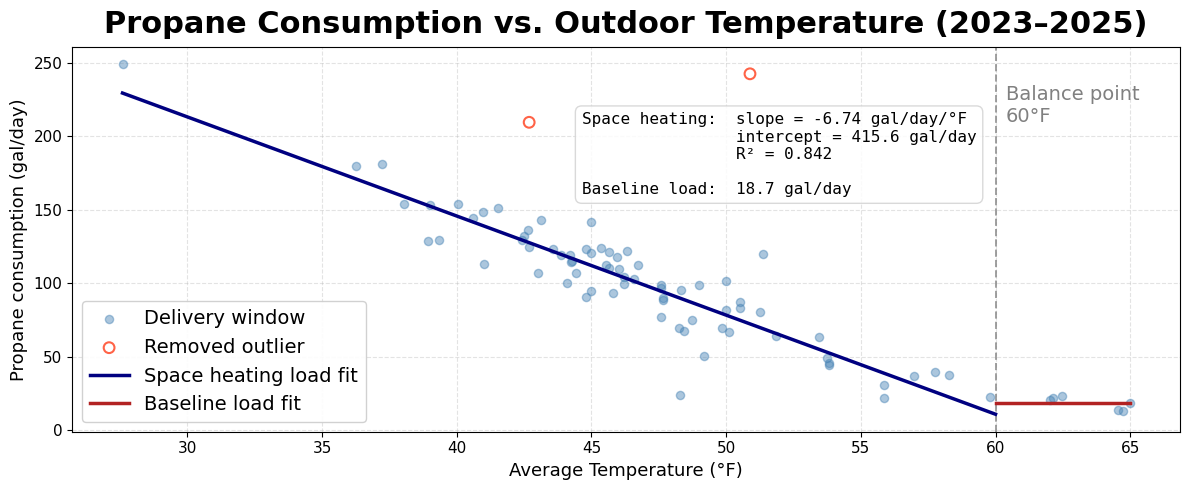

In [8]:
# ----------------------------
# Statistics + plot
# ----------------------------
print(
    f"Delivery chunks {WINDOW_START_YEAR}–{WINDOW_END_YEAR} (NEW temps), "
    f"Tb={Tb0}: m={m:.6f}, b={b:.4f}, baseline={baseline:.4f} (gal/day), "
    f"R2_heat={r2_heat:.3f}, R2_base={r2_base:.3f}, "
    f"n={len(chunks_clean)} (removed {N_OUTLIERS})"
)

plot_piecewise(
    chunks_clean,
    m, b, baseline,
    Tb=Tb0,
    x="temp_F",
    y="gal_per_day",
    #title="Hourly Heating Loads and Disaggregated Propane Consumption",
    figsize=(12, 5),
    outliers_df=chunks_outliers,
    n_removed=N_OUTLIERS,
    r2_heat=r2_heat,
    stats_in_plot=True,
    save_path="poster_heating_load_plot.png",
    dpi=300,
)

,Tb_F,m,b,baseline,r2_heat,r2_base
0,50,-7.708703,456.542004,48.222008,0.796445,0.0
1,51,-7.353504,441.738879,40.490581,0.787575,0.0
2,52,-6.936600,424.165325,31.558659,0.755275,0.0
3,53,-6.936600,424.165325,31.558659,0.755275,0.0
4,54,-6.959707,425.164265,25.172939,0.793443,0.0
5,55,-6.959707,425.164265,25.172939,0.793443,0.0
6,56,-7.081199,430.444728,24.903249,0.818166,0.0
7,57,-7.018673,427.712408,23.546388,0.825366,0.0
8,58,-6.913877,423.116564,21.562962,0.829677,0.0
9,59,-6.812269,418.650411,19.293075,0.833802,0.0


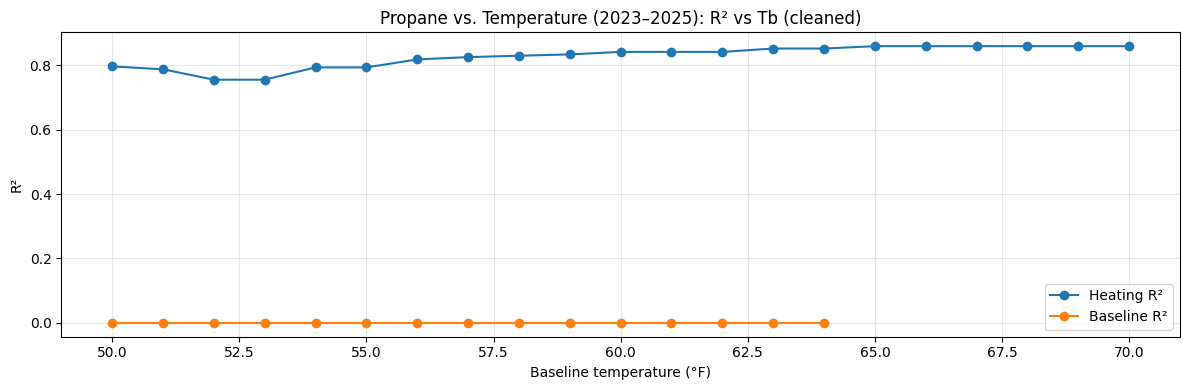

In [9]:
# ----------------------------
# Tb sweep table + plot
# ----------------------------
sweep = sweep_Tb(chunks_clean, Tb_grid=TB_SWEEP, x="temp_F", y="gal_per_day")
display(sweep)

plt.figure(figsize=(12, 4))
plt.plot(sweep["Tb_F"], sweep["r2_heat"], marker="o", label="Heating R²")
plt.plot(sweep["Tb_F"], sweep["r2_base"], marker="o", label="Baseline R²")
plt.xlabel("Baseline temperature (°F)")
plt.ylabel("R²")
plt.title(f"Propane vs. Temperature ({WINDOW_START_YEAR}–{WINDOW_END_YEAR}): R² vs Tb (cleaned)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# ----------------------------
# Export
# ----------------------------
params = {
    "window": f"{WINDOW_START_YEAR}-{WINDOW_END_YEAR}",
    "m": float(m),
    "b": float(b),
    "baseline_gpd": float(baseline),
    "r2_heating": None if pd.isna(r2_heat) else round(float(r2_heat), 4),
    "r2_baseline": None if pd.isna(r2_base) else round(float(r2_base), 4),
}

with open(PARAMS_JSON_PATH, "w") as f:
    json.dump(params, f, indent=2)

chunks_win.to_csv(WINDOW_CSV_PATH, index=False)

print(f"Wrote {PARAMS_JSON_PATH}")
print(f"Wrote {WINDOW_CSV_PATH}")

Wrote regression_params.json
Wrote Propane Regression Delivery Windows 2023-2025.csv


Delivery chunks 2023–2025 (NEW temps), Tb=60: m=-6.742649, b=415.5719, baseline=18.6820 (gal/day), R2_heat=0.842, R2_base=0.000, n=79 (removed 2)


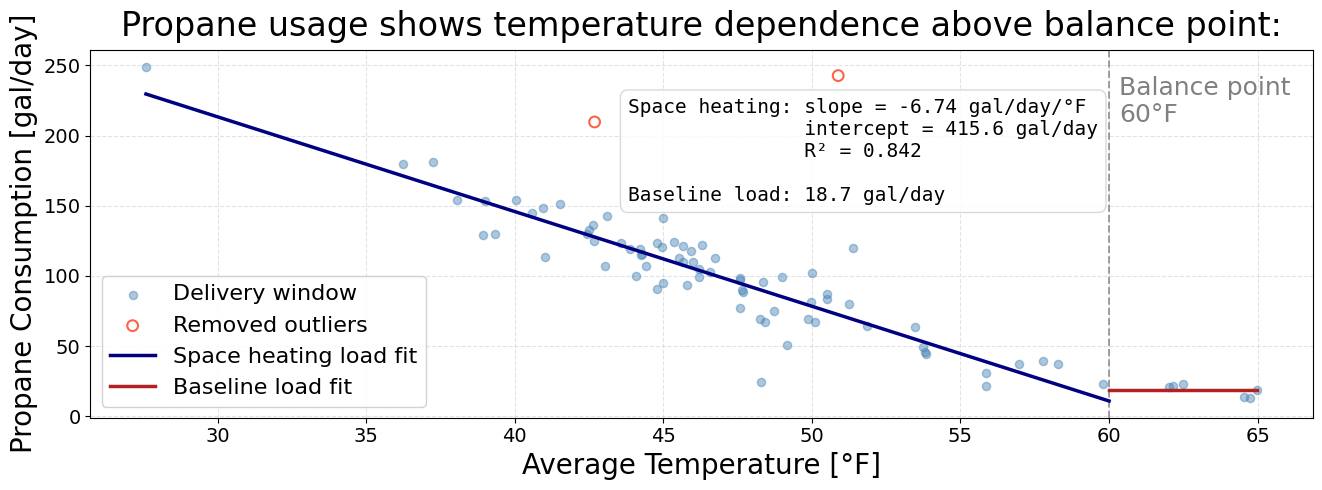

In [11]:
# ============================================================
# Drop-in final plotting cell: one place for stats + formatting
# ============================================================

def plot_piecewise(
    df, m, b, baseline, Tb=60,
    x="temp_F", y="gal_per_day",
    title="Propane usage shows temperature dependence above balance point:",
    figsize=(12, 5),
    outliers_df=None,
    r2_heat=None,
    r2_base=None,
    n_removed=0,
    stats_in_plot=True,
    print_stats=True,
    save_path=None,
    dpi=300,

    # ---- toggles / formatting you can edit in one place ----
    window_start_year=None,
    window_end_year=None,
    stats_label="NEW temps",

    scatter_color="steelblue",
    scatter_alpha=0.45,
    scatter_size=35,
    scatter_label="Delivery window",

    outlier_edgecolor="tomato",
    outlier_size=60,
    outlier_linewidth=1.5,
    outlier_label="Removed outlier",

    heat_line_color="navy",
    heat_line_width=2.5,
    heat_line_label="Space heating load fit",

    base_line_color="firebrick",
    base_line_width=2.5,
    base_line_label="Baseline load fit",

    tb_line_color="gray",
    tb_line_style="--",
    tb_line_width=1.4,
    tb_line_alpha=0.75,
    tb_text_dx=0.35,
    tb_text_y=0.93,
    tb_text_fontsize=18,

    stats_x=0.44,
    stats_y=0.87,
    stats_fontsize=14,

    xlabel="Average Temperature [°F]",
    ylabel="Propane Consumption [gal/day]",
    title_fontsize=24,
    title_fontweight="normal",
    title_fontname="Open Sans",
    label_fontsize=20,
    tick_fontsize=14,
    legend_fontsize=16,
    grid_alpha=0.35,
):
    below = df[df[x] < Tb]
    above = df[df[x] >= Tb]

    # console stats line
    if print_stats:
        year_text = ""
        if window_start_year is not None and window_end_year is not None:
            year_text = f"Delivery chunks {window_start_year}–{window_end_year} ({stats_label}), "
        print(
            f"{year_text}"
            f"Tb={Tb}: m={m:.6f}, b={b:.4f}, baseline={baseline:.4f} (gal/day), "
            f"R2_heat={r2_heat:.3f}, R2_base={r2_base:.3f}, "
            f"n={len(df)} (removed {n_removed})"
        )

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")

    # main data
    ax.scatter(
        df[x], df[y],
        color=scatter_color,
        alpha=scatter_alpha,
        s=scatter_size,
        zorder=3,
        label=scatter_label
    )

    # removed outliers
    if outliers_df is not None and len(outliers_df):
        ax.scatter(
            outliers_df[x], outliers_df[y],
            facecolors="none",
            edgecolors=outlier_edgecolor,
            s=outlier_size,
            linewidths=outlier_linewidth,
            zorder=4,
            label=outlier_label if len(outliers_df) == 1 else f"{outlier_label}s"
        )

    # heating fit
    if len(below):
        xs = np.linspace(below[x].min(), Tb, 200)
        ax.plot(
            xs, m * xs + b,
            color=heat_line_color,
            linewidth=heat_line_width,
            label=heat_line_label,
            zorder=5
        )

    # baseline fit
    if len(above):
        xs = np.linspace(Tb, above[x].max(), 200)
        ax.plot(
            xs, np.full_like(xs, baseline),
            color=base_line_color,
            linewidth=base_line_width,
            label=base_line_label,
            zorder=5
        )

    # balance point reference
    ax.axvline(
        Tb,
        color=tb_line_color,
        linestyle=tb_line_style,
        linewidth=tb_line_width,
        alpha=tb_line_alpha,
        zorder=2
    )

    ymin, ymax = ax.get_ylim()
    ax.text(
        Tb + tb_text_dx,
        ymax * tb_text_y,
        f"Balance point\n{Tb}°F",
        fontsize=tb_text_fontsize,
        color=tb_line_color,
        va="top"
    )

    # stats box
    if stats_in_plot:
        r2_heat_txt = "nan" if pd.isna(r2_heat) else f"{r2_heat:.3f}"
        r2_base_txt = "nan" if pd.isna(r2_base) else f"{r2_base:.3f}"

        stats_text = (
            f"Space heating: slope = {m:.2f} gal/day/°F\n"
            f"               intercept = {b:.1f} gal/day\n"
            f"               R² = {r2_heat_txt}\n\n"
            f"Baseline load: {baseline:.1f} gal/day"
        )
        ax.text(
            stats_x, stats_y, stats_text,
            transform=ax.transAxes,
            fontsize=stats_fontsize,
            va="top", ha="left",
            bbox=dict(
                boxstyle="round,pad=0.4",
                facecolor="white",
                edgecolor="lightgray",
                alpha=0.85
            ),
            family="monospace"
        )

    ax.set_xlabel(xlabel, fontsize=label_fontsize)
    ax.set_ylabel(ylabel, fontsize=label_fontsize)
    ax.set_title(title, fontsize=title_fontsize, fontweight=title_fontweight, pad=10)
    ax.tick_params(labelsize=tick_fontsize)
    ax.legend(fontsize=legend_fontsize, framealpha=0.9)
    ax.grid(True, linestyle="--", alpha=grid_alpha)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()


# ----------------------------
# one final call only
# ----------------------------
plot_piecewise(
    chunks_clean,
    m, b, baseline,
    Tb=Tb0,
    x="temp_F",
    y="gal_per_day",
    figsize=(13.4, 5),
    outliers_df=chunks_outliers,
    n_removed=N_OUTLIERS,
    r2_heat=r2_heat,
    r2_base=r2_base,
    stats_in_plot=True,
    print_stats=True,
    save_path="poster_heating_load_plot.png",
    dpi=300,

    window_start_year=WINDOW_START_YEAR,
    window_end_year=WINDOW_END_YEAR,
    stats_label="NEW temps",

    # title="Hourly Heating Loads and Disaggregated Propane Consumption",
)